# Fine-Tuning YOLOv8 for Whiteboard Layout Detection

Transfer-learns YOLOv8-nano (pre-trained on COCO) to detect five whiteboard-specific region classes:

| ID | Class | Description |
|----|-------|-------------|
| 0 | Handwriting | Freehand written text blocks |
| 1 | Diagram | Drawn shapes, flowcharts, circuits |
| 2 | Arrow | Directional indicators |
| 3 | Equation | Mathematical expressions |
| 4 | Sticky Note | Coloured post-it notes |

**Pipeline position:** This notebook produces `best.pt` — the checkpoint used by `src/detect_layout.py` in Stage 1 of the whiteboard digitisation pipeline.

```
fetch_real_dataset.py  →  [this notebook]  →  detect_layout.py
   (download data)         (fine-tune)         (inference)
```

> **Before running:** download the dataset first:
> ```bash
> python tests/fetch_real_dataset.py --api-key YOUR_KEY
> ```

## 0. Environment Setup

In [12]:
import sys
import platform
from pathlib import Path

import torch
import yaml
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from IPython.display import display, Image as IPImage

# ── Device detection ──────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "0"          # first NVIDIA GPU
elif torch.backends.mps.is_available():
    DEVICE = "mps"        # Apple Silicon
else:
    DEVICE = "cpu"

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"Platform: {platform.machine()} / {platform.system()}")
print(f"Device  : {DEVICE}")

Python  : 3.9.6
PyTorch : 2.8.0
Platform: arm64 / Darwin
Device  : mps


## 1. Configuration

All training hyperparameters are defined in one place. Edit here — do not scatter magic numbers through later cells.

**Apple Silicon (M1/M2/M3) recommended values:** `BATCH=8`, `WORKERS=0`, `DEVICE="mps"`

In [13]:
# ── Repo root ─────────────────────────────────────────────────────────────────
from IPython import get_ipython as _get_ip

_ip      = _get_ip()
_nb_file = _ip.user_ns.get("__vsc_ipynb_file__") if _ip else None

if _nb_file:
    _candidate = Path(_nb_file).resolve().parent.parent
    REPO_ROOT  = _candidate if (_candidate / "requirements.txt").exists() else None
else:
    REPO_ROOT = None

if REPO_ROOT is None:
    for _candidate in [Path.cwd(), *Path.cwd().parents]:
        if (_candidate / "requirements.txt").exists():
            REPO_ROOT = _candidate
            break

if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the repo root (requirements.txt not found).\n"
        "Open the notebook from inside the mla-proj directory."
    )

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_YAML = REPO_ROOT / "data" / "dataset.yaml"
RUNS_DIR  = REPO_ROOT / "runs" / "detect"

# ── Model ─────────────────────────────────────────────────────────────────────
BASE_MODEL = "yolov8n.pt"   # nano: fastest; swap to yolov8s.pt for more capacity
EXPERIMENT = "whiteboard_mathwriting_v1"

# ── Training hyperparameters ──────────────────────────────────────────────────
EPOCHS   = 50
PATIENCE = 20    # early-stopping: halt if val mAP stalls for N epochs
IMGSZ    = 640
BATCH    = 8     # 8 for MPS / 16 GB RAM; 16 if you have 32 GB or NVIDIA GPU
WORKERS  = 0     # 0 required on MPS; 4 is fine on Linux/NVIDIA

# ── Whiteboard-specific augmentations ────────────────────────────────────────
AUG = dict(
    hsv_h   = 0.01,   # hue shift — whiteboard lighting variation
    hsv_s   = 0.30,   # saturation jitter — marker colour variation
    hsv_v   = 0.40,   # brightness jitter — glare and shadows
    fliplr  = 0.50,   # horizontal flip
    degrees = 5.0,    # rotation — camera tilt correction
    scale   = 0.50,   # zoom variation
    mosaic  = 1.00,   # mosaic augmentation — helps on small datasets
)

print(f"Repo root    : {REPO_ROOT}")
print(f"Dataset YAML : {DATA_YAML}")
print(f"Base model   : {BASE_MODEL}")
print(f"Experiment   : {EXPERIMENT}")
print(f"Device       : {DEVICE}")
print(f"Epochs       : {EPOCHS}  (early stop after {PATIENCE} stale epochs)")
print(f"Batch / imgsz: {BATCH} / {IMGSZ}px")

Repo root    : /Users/nghia/Developer/mla-proj
Dataset YAML : /Users/nghia/Developer/mla-proj/data/dataset.yaml
Base model   : yolov8n.pt
Experiment   : whiteboard_mathwriting_v1
Device       : mps
Epochs       : 50  (early stop after 20 stale epochs)
Batch / imgsz: 8 / 640px


## 2. Dataset Validation

Confirm the dataset is present and correctly structured before spending time on training.

In [14]:
assert DATA_YAML.exists(), (
    f"dataset.yaml not found at {DATA_YAML}.\n"
    "Run: python tests/fetch_real_dataset.py --api-key YOUR_KEY"
)

with DATA_YAML.open() as f:
    meta = yaml.safe_load(f)

dataset_root = Path(meta["path"])
train_img_dir = dataset_root / meta["train"]
val_img_dir   = dataset_root / meta["val"].strip()

IMG_EXTS = {".jpg", ".jpeg", ".png"}

def count_images(d: Path) -> int:
    return sum(1 for p in d.iterdir() if p.suffix.lower() in IMG_EXTS) if d.exists() else 0

n_train = count_images(train_img_dir)
n_val   = count_images(val_img_dir)
nc      = meta.get("nc", len(meta.get("names", [])))
names   = meta.get("names", [])

print("Dataset summary")
print("═" * 40)
print(f"  Root        : {dataset_root}")
print(f"  Train images: {n_train}")
print(f"  Val images  : {n_val}")
print(f"  Classes ({nc}): {names}")
print()

assert n_train > 0, f"No training images found in {train_img_dir}"
assert n_val   > 0, f"No validation images found in {val_img_dir}"
print("Dataset OK.")

Dataset summary
════════════════════════════════════════
  Root        : /Users/nghia/Developer/mla-proj/data/raw/mathwriting
  Train images: 425
  Val images  : 75
  Classes (5): ['Handwriting', 'Diagram', 'Arrow', 'Equation', 'Sticky Note']

Dataset OK.


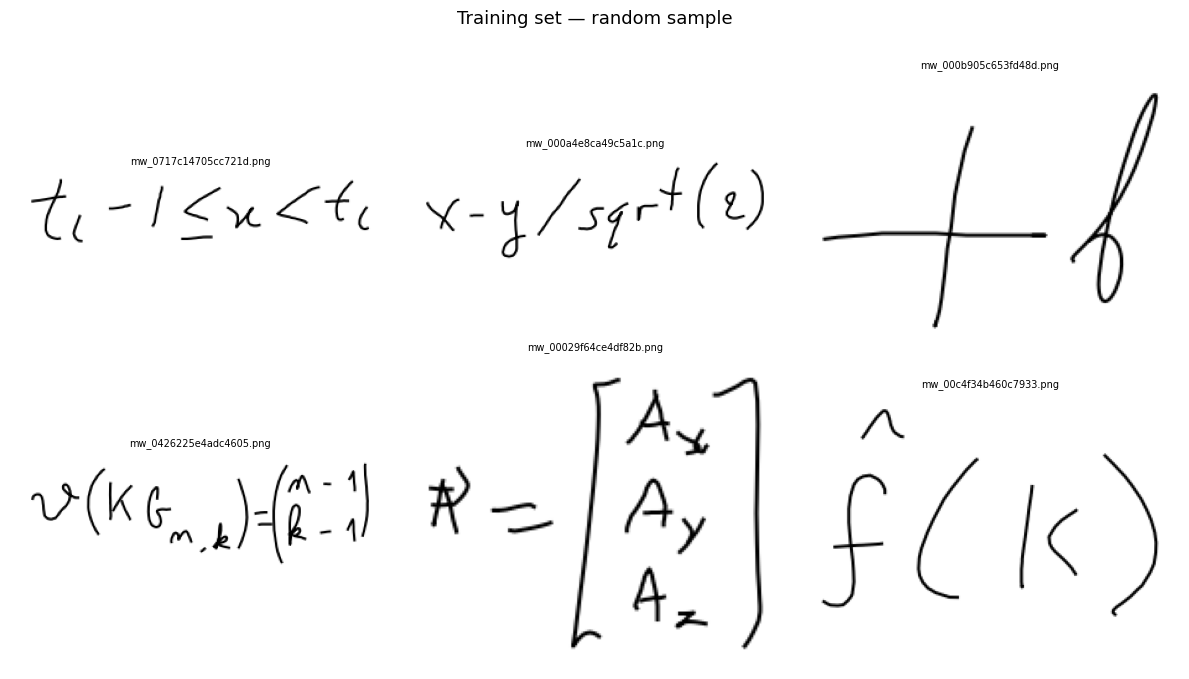

In [15]:
# Preview a random sample of training images
import random

sample_paths = random.sample(
    [p for p in train_img_dir.iterdir() if p.suffix.lower() in IMG_EXTS],
    k=min(6, n_train)
)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle("Training set — random sample", fontsize=13)

for ax, img_path in zip(axes.flat, sample_paths):
    img = mpimg.imread(str(img_path))
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=7)
    ax.axis("off")

# Hide any unused axes
for ax in axes.flat[len(sample_paths):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 3. Model Initialisation

Load the COCO pre-trained YOLOv8-nano backbone. The detection head will be automatically replaced with `nc` outputs when training starts.

In [16]:
from ultralytics import YOLO

model = YOLO(BASE_MODEL)

print(f"Model      : {BASE_MODEL}")
print(f"Parameters : {sum(p.numel() for p in model.model.parameters()):,}")
print(f"Task       : {model.task}")

Model      : yolov8n.pt
Parameters : 3,157,200
Task       : detect


## 4. Training

Transfer-learning strategy:
- The COCO backbone already understands low-level visual features (edges, textures, shapes).
- All layers are fine-tuned on the whiteboard dataset.
- Early stopping (`PATIENCE`) prevents overfitting on the relatively small dataset.

Training logs and checkpoints are saved to `runs/detect/{EXPERIMENT}/`.

In [17]:
results = model.train(
    data    = str(DATA_YAML),
    epochs  = EPOCHS,
    patience= PATIENCE,
    imgsz   = IMGSZ,
    batch   = BATCH,
    workers = WORKERS,
    device  = DEVICE,
    name    = EXPERIMENT,
    project = str(RUNS_DIR),
    **AUG,
)

BEST_PT = RUNS_DIR / EXPERIMENT / "weights" / "best.pt"
print(f"\nTraining complete.")
print(f"Best checkpoint : {BEST_PT}")

New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.33 🚀 Python-3.9.6 torch-2.8.0 MPS (Apple M1 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/nghia/Developer/mla-proj/data/dataset.yaml, degrees=5.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=whiteboard_mat

## 5. Training Curves

Inspect loss and mAP over epochs. Good signs:
- Train and val loss curves track each other (no large gap = no overfitting).
- `mAP50` climbs and plateaus — training converged.

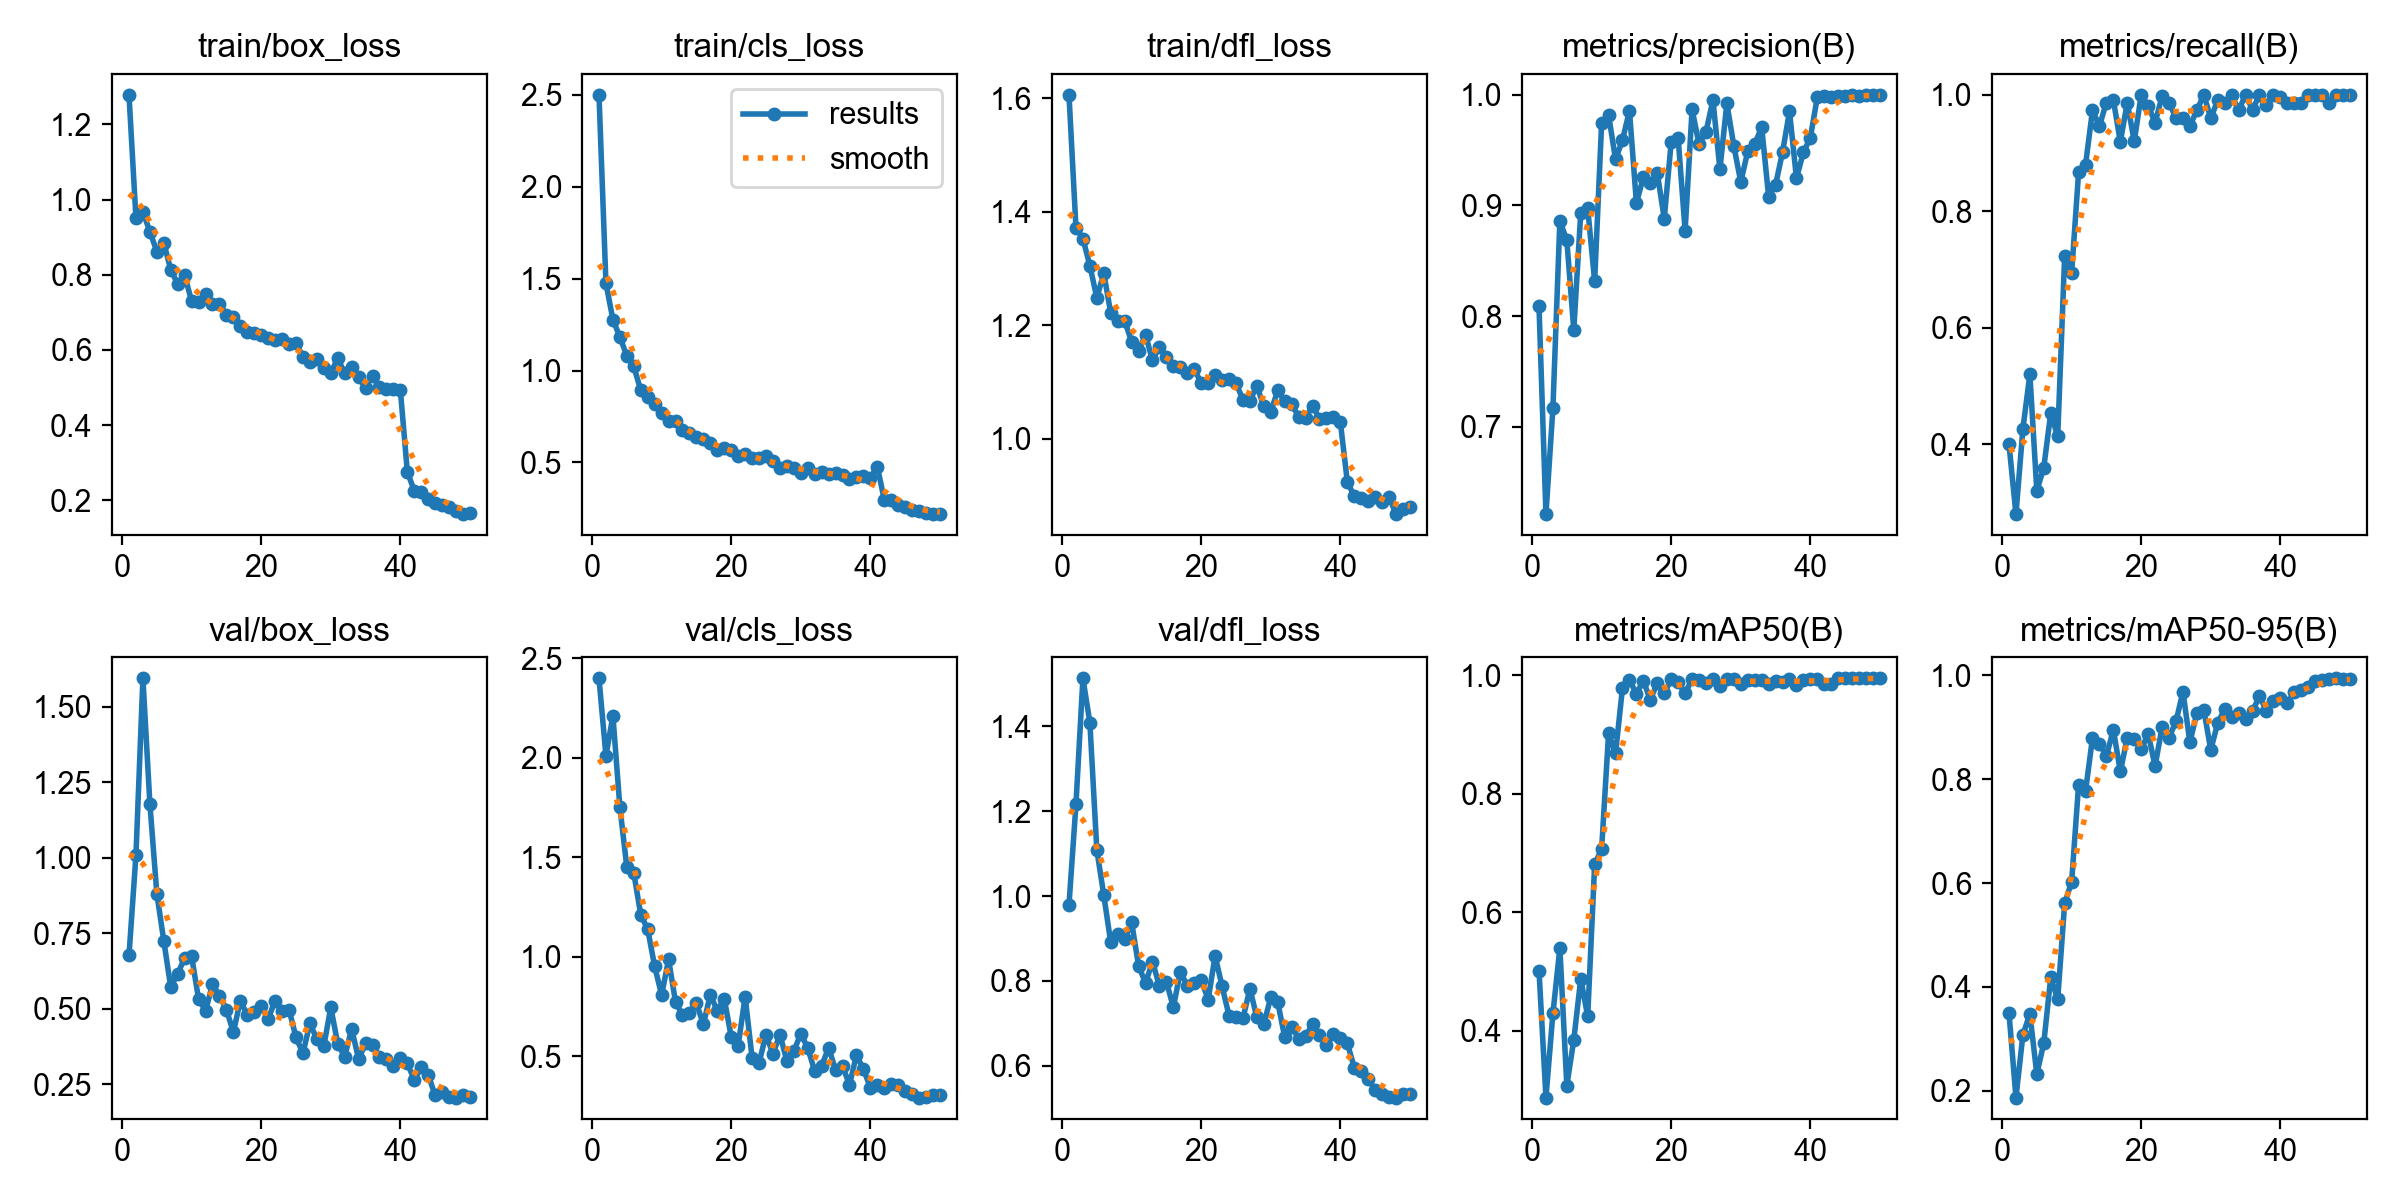

In [22]:
results_png = RUNS_DIR / EXPERIMENT / "results.png"

if results_png.exists():
    display(IPImage(filename=str(results_png)))
else:
    print(f"[WARN] results.png not found at {results_png}")

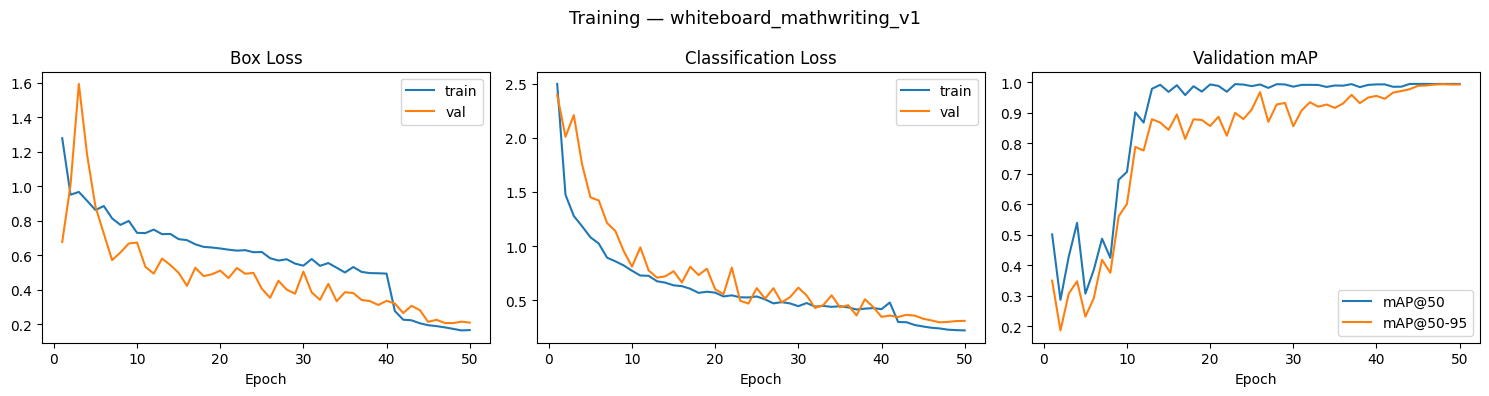

In [23]:
# Plot the metrics CSV for an interactive view
import pandas as pd

csv_path = RUNS_DIR / EXPERIMENT / "results.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Training — {EXPERIMENT}", fontsize=13)

    # Box loss
    axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
    axes[0].plot(df["epoch"], df["val/box_loss"],   label="val")
    axes[0].set_title("Box Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    # Classification loss
    axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
    axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val")
    axes[1].set_title("Classification Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    # mAP
    axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],    label="mAP@50")
    axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@50-95")
    axes[2].set_title("Validation mAP")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print(f"[WARN] results.csv not found at {csv_path}")

## 6. Validation Metrics

Run the best checkpoint on the validation set and report per-class precision, recall, and mAP.

In [24]:
assert BEST_PT.exists(), f"Checkpoint not found: {BEST_PT}. Did training complete?"

best_model = YOLO(str(BEST_PT))
metrics    = best_model.val(data=str(DATA_YAML), device=DEVICE)

print()
print("Validation Results")
print("═" * 45)
print(f"  mAP@50     : {metrics.box.map50:.4f}")
print(f"  mAP@50-95  : {metrics.box.map:.4f}")
print(f"  Precision  : {metrics.box.mp:.4f}")
print(f"  Recall     : {metrics.box.mr:.4f}")
print("═" * 45)
print()

# Per-class breakdown
class_names = list(names.values()) if isinstance(names, dict) else names
print(f"{'Class':<16} {'AP@50':>8}")
print("-" * 26)
for cls_name, ap in zip(class_names, metrics.box.ap50):
    print(f"  {cls_name:<14} {ap:.4f}")

Ultralytics 8.4.33 🚀 Python-3.9.6 torch-2.8.0 MPS (Apple M1 Pro)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 13.3±5.2 MB/s, size: 3.9 KB)
val: Scanning /Users/nghia/Developer/mla-proj/data/raw/mathwriting/valid/labels.cache... 75 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 75/75 15.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.7it/s 2.9s0.8s
                   all         75         75          1          1      0.995      0.994
              Equation         75         75          1          1      0.995      0.994
Speed: 0.1ms preprocess, 12.8ms inference, 0.0ms loss, 6.4ms postprocess per image
Results saved to /Users/nghia/Developer/mla-proj/runs/detect/val2

Validation Results
═════════════════════════════════════════════
  mAP@50     : 0.9950
  mAP@50-95  : 0.9940
  Precision  : 0.9997
  Recall     : 1.0000
═

## 7. Deploy

Update `src/detect_layout.py` to use the fine-tuned checkpoint and matching class names.

In [25]:
detect_py = REPO_ROOT / "src" / "detect_layout.py"

class_names = list(names.values()) if isinstance(names, dict) else names
class_names_repr = "{\n" + ",\n".join(
    f'    {i}: "{n}"' for i, n in enumerate(class_names)
) + "\n}"

print("Update the following two constants in src/detect_layout.py:")
print("═" * 58)
print(f'DEFAULT_MODEL_PATH: str = "{BEST_PT}"')
print()
print(f"CLASS_NAMES: dict[int, str] = {class_names_repr}")
print("═" * 58)
print()
print("Then test on real images:")
print(f"  python tests/test_pipeline.py --model {BEST_PT}")

Update the following two constants in src/detect_layout.py:
══════════════════════════════════════════════════════════
DEFAULT_MODEL_PATH: str = "/Users/nghia/Developer/mla-proj/runs/detect/whiteboard_mathwriting_v1/weights/best.pt"

CLASS_NAMES: dict[int, str] = {
    0: "Handwriting",
    1: "Diagram",
    2: "Arrow",
    3: "Equation",
    4: "Sticky Note"
}
══════════════════════════════════════════════════════════

Then test on real images:
  python tests/test_pipeline.py --model /Users/nghia/Developer/mla-proj/runs/detect/whiteboard_mathwriting_v1/weights/best.pt
